In [1]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
print(image.height, image.width)  # [480, 640]

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base', device_map="auto")
patch_size = model.config.patch_size

inputs = processor(images=image, return_tensors="pt").to(model.device)
print(inputs.pixel_values.shape)  # [1, 3, 224, 224]
batch_size, rgb, img_height, img_width = inputs.pixel_values.shape
num_patches_height, num_patches_width = img_height // patch_size, img_width // patch_size
num_patches_flat = num_patches_height * num_patches_width

outputs = model(**inputs)
last_hidden_states = outputs[0]
print(last_hidden_states.shape)  # [1, 1 + 256, 768]
assert last_hidden_states.shape == (batch_size, 1 + num_patches_flat, model.config.hidden_size)

cls_token = last_hidden_states[:, 0, :]
patch_features = last_hidden_states[:, 1:, :].unflatten(1, (num_patches_height, num_patches_width))

480 640


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

torch.Size([1, 3, 224, 224])
torch.Size([1, 257, 768])


In [9]:
model.config

Dinov2Config {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 518,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "transformers_version": "5.13.1",
  "use_mask_token": true,
  "use_swiglu_ffn": false
}

In [6]:
outputs['last_hidden_state'].shape

torch.Size([1, 257, 768])

In [2]:
import h5py, io, numpy as np, decord

f = h5py.File('datasets/uniform_motion_30K.hdf5', 'r')

shard, i = '00000', 0
pos    = f[f'position_streams/{shard}'][i]           # (32, 2)
init   = f[f'init_streams/{shard}'][i]               # (2,)
mp4    = f[f'video_streams/{shard}'][i].tobytes()    # raw MP4 bytes
frames = decord.VideoReader(io.BytesIO(mp4))[:].asnumpy()  # (32, 256, 256, 3) uint8

# global index 0..29999 -> (shard, row)
def get(idx):
    s, r = divmod(idx, 1000)
    k = f'{s:05d}'
    return (decord.VideoReader(io.BytesIO(f[f'video_streams/{k}'][r].tobytes()))[:].asnumpy(),
            f[f'position_streams/{k}'][r])


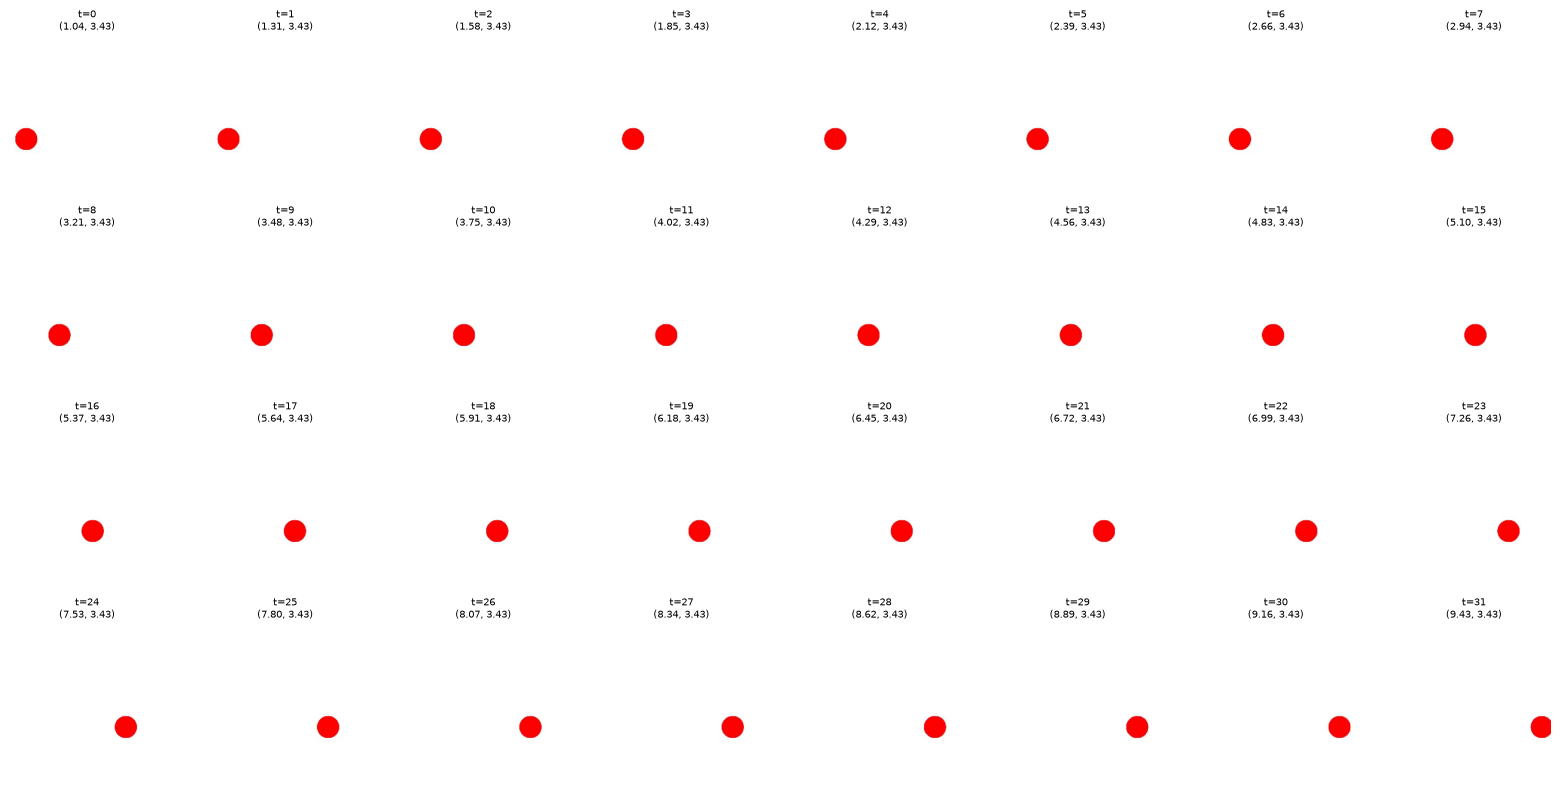

In [6]:
import h5py, io, numpy as np, decord
import matplotlib.pyplot as plt

f = h5py.File('datasets/uniform_motion_30K.hdf5', 'r')

def load_clip(idx):
    s, r = divmod(idx, 1000)
    k = f'{s:05d}'
    mp4 = f[f'video_streams/{k}'][r].tobytes()
    frames = decord.VideoReader(io.BytesIO(mp4))[:].asnumpy()   # (32, 256, 256, 3)
    pos = f[f'position_streams/{k}'][r]                          # (32, 2)
    return frames, pos

def plot_frames(frames, pos=None, ncols=8, size=2):
    T = len(frames)
    nrows = int(np.ceil(T / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for t, ax in enumerate(axes.flat):
        ax.axis('off')
        if t >= T:
            continue
        ax.imshow(frames[t])
        title = f't={t}'
        if pos is not None:
            title += f'\n({pos[t,0]:.2f}, {pos[t,1]:.2f})'
        ax.set_title(title, fontsize=7)
    plt.tight_layout()
    plt.show()

frames, pos = load_clip(10)
plot_frames(frames, pos)
